In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [21]:
#creating data and dataframe
data = {
    'Revenue': [50000, 62000, 58000, 75000, 80000, 45000, 67000, 52000, 78000, 56000],
    'Profit': [12000, 15000, 10000, 20000, 25000, 8000, 16000, 11000, 24000, 12000],
    'Expenses': [38000, 47000, 48000, 55000, 55000, 37000, 51000, 41000, 54000, 44000],
    'Region': ['North', 'South', 'North', 'West', 'West', 'South', 'North', 'South', 'West', 'North']
}
df = pd.DataFrame(data)
df

,Revenue,Profit,Expenses,Region
0,50000,12000,38000,North
1,62000,15000,47000,South
2,58000,10000,48000,North
3,75000,20000,55000,West
4,80000,25000,55000,West
5,45000,8000,37000,South
6,67000,16000,51000,North
7,52000,11000,41000,South
8,78000,24000,54000,West
9,56000,12000,44000,North


In [22]:
#normalizing numerical columns for clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[['Revenue', 'Profit', 'Expenses']])
scaled_data

array([[-1.05545382, -0.5888165 , -1.38873015],
       [-0.02574278, -0.05352877,  0.        ],
       [-0.36897979, -0.94567499,  0.15430335],
       [ 1.08977752,  0.83861744,  1.2344268 ],
       [ 1.51882379,  1.73076365,  1.2344268 ],
       [-1.48450009, -1.30253347, -1.5430335 ],
       [ 0.40330349,  0.12490047,  0.6172134 ],
       [-0.88383531, -0.76724574, -0.9258201 ],
       [ 1.34720528,  1.55233441,  1.08012345],
       [-0.5405983 , -0.5888165 , -0.46291005]])

In [23]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)
df.to_csv('clustered_data.csv', index=False)
df

,Revenue,Profit,Expenses,Region,Cluster
0,50000,12000,38000,North,1
1,62000,15000,47000,South,2
2,58000,10000,48000,North,2
3,75000,20000,55000,West,0
4,80000,25000,55000,West,0
5,45000,8000,37000,South,1
6,67000,16000,51000,North,2
7,52000,11000,41000,South,1
8,78000,24000,54000,West,0
9,56000,12000,44000,North,1


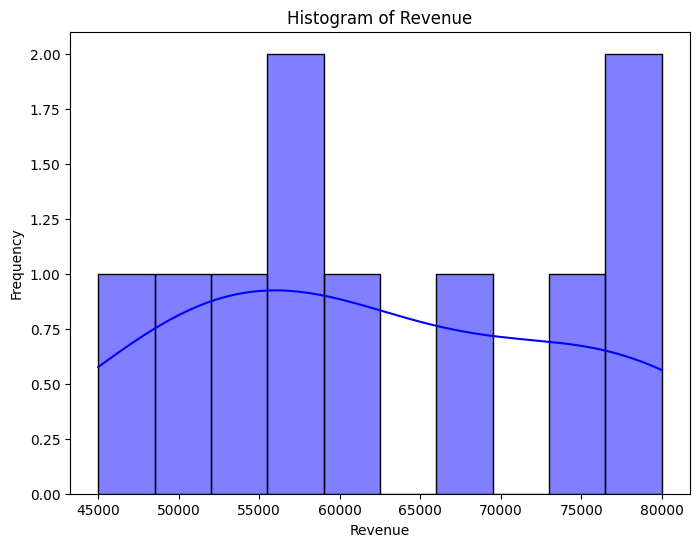

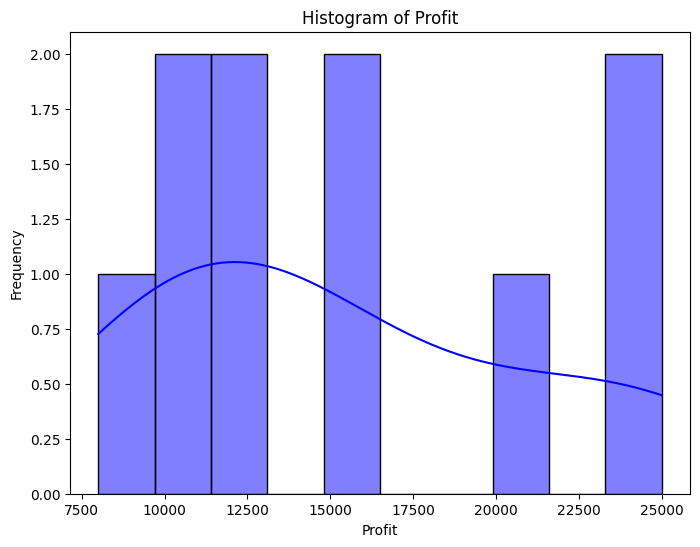

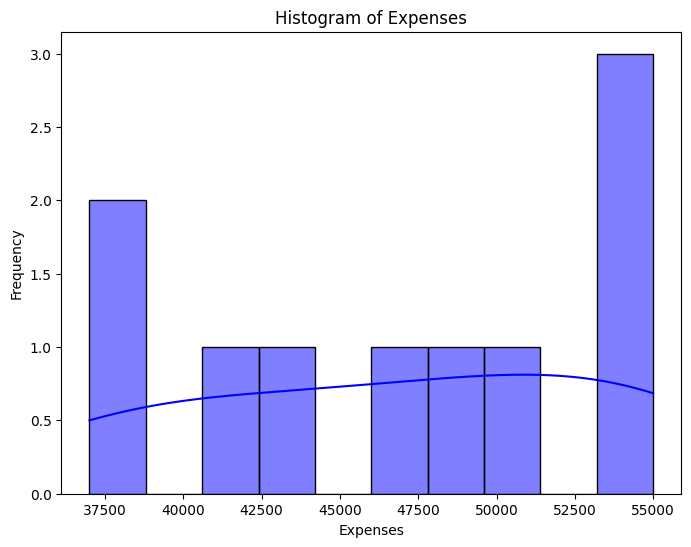


Histograms generated and saved as PNG files.


In [24]:
for column in ['Revenue', 'Profit', 'Expenses']:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[column], kde=True, bins=10, color='blue')
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.savefig(f"histogram_{column}.png")  # Save for visualization
    plt.show()
    plt.close()

print("\nHistograms generated and saved as PNG files.")


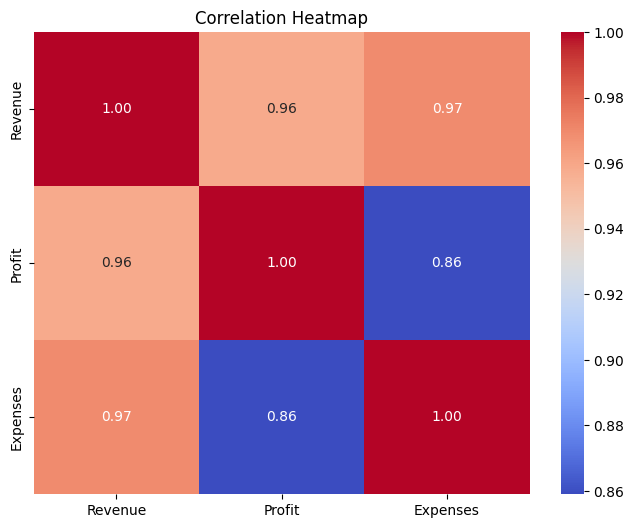

In [25]:
correlation_matrix = df[['Revenue', 'Profit', 'Expenses']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")  # Save for visualization